# Calculate Derivative

This jupyter notebook computes the basis functions and triangle area for FESOM1.4 mesh files.\
In addition it has some control calculations and plots.

In [1]:
# Data handling
import netCDF4 as nc
import pandas as pd
import pyfesom as pf

# General
import numpy as np
from tqdm import tqdm
import glob

# Plotting
import matplotlib.pyplot as plt
import xarray as xr

# custom
import sys
sys.path.append('/albedo/work/user/quraus001/FESOM_particles/analysis/functions/')
import helper as hlp
import FESOM_plotting as fplt

logger = hlp.get_logger("DEBUG", "calc_bafu")

/albedo/home/quraus001/pyfesom/pyfesom/climatology.py:21: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


## Calculate BaFu

In [2]:
# Constants
domain_length = 360.
R = 6371220

# Read mesh file
meshpath='/albedo/work/projects/oce_rio/cwekerle/mesh/Arc08_sub/'
df_mesh = pd.read_csv(meshpath + 'nod2d.out', header=None, skiprows=1, sep='\s+')#, delim_whitespace=True
df_mesh.columns = ['node', 'xcoord', 'ycoord', 'boundary']

xcoord = df_mesh['xcoord'].values
ycoord = df_mesh['ycoord'].values

# rotate lat and lon
al, be, ga = 50, 15, -90
xcoord, ycoord = pf.scalar_r2g(al, be, ga, xcoord, ycoord)
n2d = xcoord.size

df_elem = pd.read_csv(meshpath + 'elem2d.out', sep='\s+', header=None, skiprows=1)
df_elem.columns = ['node1', 'node2', 'node3']
el2d = len(df_elem)
logger.info(f"Number of elements: {el2d}")

elem_back = df_elem.to_numpy().T # columns to 3x el2d matrix
elem_back -= 1                   # convert to python counting
logger.info(f"Shape of elem_back: {elem_back.shape}")

domain_len = domain_length * np.pi / 180
logger.info(f"Domain length (radians): {domain_len:.2f}, Domain length (degrees): {domain_length:.2f}")

# Outputs
bafux_2d = np.zeros((3, el2d))
bafuy_2d = np.zeros((3, el2d))
voltriangle = np.zeros(el2d)
full_cluster_area = np.zeros(n2d)

# Standard derivatives in reference triangle
deriv_std = np.zeros((2, 3))
deriv_std[:, 0] = -1.
deriv_std[0, 1] = 1.
deriv_std[1, 2] = 1.
logger.debug(f"Standard derivatives (reference triangle): {deriv_std}")

local_cart = np.zeros((2, 3))

# ------------------------------------------------------------------
# Loop over all triangular elements
#
# For each element:
#   1. Convert node coordinates from degrees to radians
#   2. Build the Jacobian mapping from reference → physical space
#   3. Apply periodic longitude correction (cyclic domain)
#   4. Apply spherical metric correction (cos(latitude))
#   5. Compute inverse Jacobian and shape-function derivatives
#   6. Compute triangle area and accumulate nodal areas
# ------------------------------------------------------------------
for i in tqdm(range(el2d)):
    node = elem_back[:, i] # Element node indices (already converted to 0-based indexing)
    # Local coordinates of the triangle nodes (radians)
    local_cart[0, :] = xcoord[node] * np.pi/180
    local_cart[1, :] = ycoord[node] * np.pi/180

    # Jacobian
    jac = np.zeros((2,3))
    jac = local_cart[:, [1,2]]-local_cart[:, [0, 0]]

    # Cyclic correction
    for j in range(2):
        if jac[0, j] > domain_len / 3.0:
            jac[0, j] -= domain_len
        if jac[0, j] < -domain_len / 3.0:
            jac[0, j] += domain_len

    # Convert angular distances (radians) to physical distances (m)
    jac = jac * R

    # Spherical metric correction:
    #   scale longitudinal distances by cos(latitude) using the mean latitude of the triangle
    jac[0,:] = jac[0,:] * np.mean(np.cos(local_cart[1,:]))

    # Inverse Jacobian and shape-function derivatives
    jac_inv = np.linalg.inv(jac)
    deriv_local = (deriv_std.T @ jac_inv).T
    bafux_2d[:, i] = deriv_local[0, :]
    bafuy_2d[:, i] = deriv_local[1, :]

    # Triangle area
    voltriangle[i] = 0.5 * abs(np.linalg.det(jac))
    # Accumulate element area to its nodes
    full_cluster_area[node] += voltriangle[i]



Number of elements: 1133878
Shape of elem_back: (3, 1133878)
Domain length (radians): 6.28, Domain length (degrees): 360.00
Standard derivatives (reference triangle): [[-1.  1.  0.]
 [-1.  0.  1.]]


100%|██████████| 1133878/1133878 [01:11<00:00, 15871.04it/s]


## Control BaFu

Gradient recovery test


In [3]:
# Constants (must match values used in Jacobian construction)
R = 6371220.0
domain_len = 2 * np.pi        # full periodic longitude range (360° in radians)


def xy_meters_like_J(e, xdeg, ydeg, elem_back):
    """
    Reconstruct local Cartesian coordinates (meters) for one element
    using *exactly* the same assumptions as the Jacobian construction.

    This is used as a consistency check for the recovered gradients.
    """

    
    nodes = elem_back[:, e]           # shape (3,)  Element node indices

    # Node coordinates in radians
    lon = np.deg2rad(xdeg[nodes])     # longitude [rad]
    lat = np.deg2rad(ydeg[nodes])     # latitude  [rad]

    # Coordinate differences relative to first node (same reference choice as in Jacobian)
    dlon = lon - lon[0]
    dlat = lat - lat[0]

    # Periodic longitude correction
    #   Ensures minimal longitudinal distance when the element
    #   crosses the cyclic domain boundary.
    for j in range(3):
        if dlon[j] > domain_len / 3.0:
            dlon[j] -= domain_len
        elif dlon[j] < -domain_len / 3.0:
            dlon[j] += domain_len

    # Convert angular distances to meters
    mean_lat = np.mean(lat)

    x_m = R * np.cos(mean_lat) * dlon
    y_m = R * dlat

    return x_m, y_m


# Gradient recovery test
#
# Define a linear function f(x, y) = a*x + b*y on the element
# and verify that the recovered gradients match (a, b).

e = 519505 - 1   # element index (0-based)

# Local Cartesian coordinates consistent with Jacobian
x_m, y_m = xy_meters_like_J(e, xcoord, ycoord, elem_back)

# Prescribed linear field
a, b = 1.7, -0.9
f_nodes = a * x_m + b * y_m

# Recovered gradients from FEM shape-function derivatives
gx = float((f_nodes * bafux_2d[:, e]).sum())
gy = float((f_nodes * bafuy_2d[:, e]).sum())

print("recovered:", gx, gy, " expected:", a, b)

recovered: 1.7000000048897355 -0.9000000000000004  expected: 1.7 -0.9


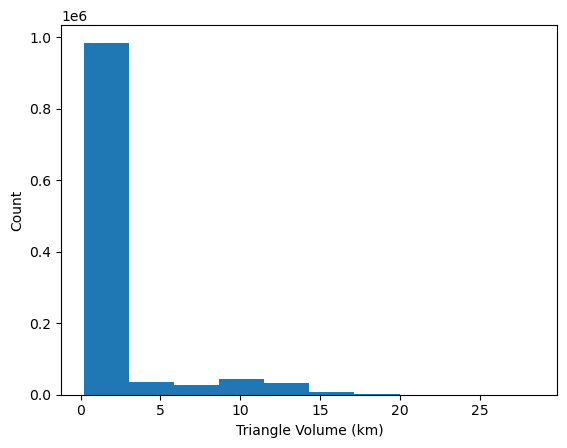

In [7]:
plt.hist(voltriangle/(1000*1000))
plt.xlabel("Triangle Volume (km)")
plt.ylabel("Count")
plt.show()

## Save to NetCDF

In [4]:
# save  bafux_2d and bafuy_2d to netCDF file
output_path = '/albedo/work/user/quraus001/FESOM_particles/preparation/'
output_file = output_path + 'bafux_bafuy_2d.nc'
with nc.Dataset(output_file, 'w', format='NETCDF4') as ds:
    ds.createDimension('el2d', el2d)
    ds.createDimension('node', 3)
    ds.createDimension('n2d', n2d)
    
    bafux_var = ds.createVariable('bafux_2d', 'f8', ('node', 'el2d'))
    bafuy_var = ds.createVariable('bafuy_2d', 'f8', ('node', 'el2d'))
    full_area_var = ds.createVariable('full_cluster_area', 'f8', ('n2d',))
    voltriangle_var = ds.createVariable('voltriangle', 'f8', ('el2d',))
    
    bafux_var[:] = bafux_2d
    bafuy_var[:] = bafuy_2d
    full_area_var[:] = full_cluster_area
    voltriangle_var[:] = voltriangle

    ds.description = 'Geometric derivatives for FESOM Arctic Mesh'
    ds.history = 'Created on ' + pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

    # write long names
    bafux_var.long_name = 'Basis function x-derivative (2D)'
    bafuy_var.long_name = 'Basis function y-derivative (2D)'
    full_area_var.long_name = 'Full cluster area'
    voltriangle_var.long_name = 'Volume of triangle'

    full_area_var.description = 'Area of each node in the mesh, computed from the triangles'


## Test Plots & Calculations

In [11]:

# Load the FESOM mesh
meshpath = '/albedo/home/quraus001/Arc08_sub/'
mesh = pf.load_mesh(meshpath)

# Load the freshly made BaFu file
output_path = '/albedo/work/user/quraus001/FESOM_particles/preparation/'
output_file = output_path + 'bafux_bafuy_2d.nc' 

ds_bafu = xr.open_dataset(output_file)
ds_bafu

/albedo/home/quraus001/Arc08_sub/pickle_mesh_py3
3
The usepickle == True)
The pickle file for python 3 exists.
The mesh will be loaded from /albedo/home/quraus001/Arc08_sub/pickle_mesh_py3


<xarray.Dataset> Size: 68MB
Dimensions:            (node: 3, el2d: 1133878, n2d: 570732)
Dimensions without coordinates: node, el2d, n2d
Data variables:
    bafux_2d           (node, el2d) float64 27MB ...
    bafuy_2d           (node, el2d) float64 27MB ...
    full_cluster_area  (n2d) float64 5MB ...
    voltriangle        (el2d) float64 9MB ...
Attributes:
    description:  Geometric derivatives for FESOM Arctic Mesh
    history:      Created on 2025-08-25 11:26:20

### Calculate Vorticity

In [12]:
depth = 100
time_idx = 1
year = 2006

file = glob.glob(f"/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/*{year}.oce.mean.sub.nc")[0]
ds_pf = xr.open_dataset(file)
print("Loading data with timestamp:", ds_pf.time[time_idx].values)
level_data_u, elem_no_nan = pf.get_data(ds_pf['u'][time_idx,:],mesh,depth) # extract data from a specific model depth level
level_data_v, elem_no_nan = pf.get_data(ds_pf['v'][time_idx,:],mesh,depth)

al, be, ga = mesh.alpha, mesh.beta, mesh.gamma
print(al, be, ga)

u, v = pf.vec_rotate_r2g(al, be, ga , mesh.x2, mesh.y2, level_data_u, level_data_v, flag=1) # rotate to true north

f = 2 * (2 * np.pi / 86164) * np.sin(np.radians(mesh.y2))


Loading data with timestamp: 2006-01-02 23:57:30
For depth 100 model level 100.0 will be used
For depth 100 model level 100.0 will be used
50 15 -90


In [14]:
df_elem = pd.read_csv(meshpath + 'elem2d.out', sep='\s+', header=None, skiprows=1)
df_elem.columns = ['node1', 'node2', 'node3']
elem_back = df_elem.to_numpy().T # columns to 3x el2d matrix
elem_back -= 1                   # convert to python counting

def calc_derivative(vx2d, ds, elem_back, n2d):
    """Calculate the spatial derivatives (x and y) of a 2D nodal variable.

    This function computes the derivatives of a given variable on a triangular 
    mesh. It first calculates the gradients within each triangle using basis 
    functions, distributes the area-weighted gradients back to the mesh nodes, 
    and normalizes them by the total cluster area of each node.

    Args:
        vx2d (np.ndarray): 
            A 1D array of shape `(n2d,)` containing the variable values at 
            the mesh nodes.
        ds (xarray.Dataset): 
            A dataset containing mesh geometric properties:
            - `bafux_2d`: Basis function x-gradients, shape `(3, el2d)`.
            - `bafuy_2d`: Basis function y-gradients, shape `(3, el2d)`.
            - `voltriangle`: Area of each triangle, shape `(el2d,)`.
            - `full_cluster_area`: Total surrounding area for each node, shape `(n2d,)`.
        elem_back (np.ndarray): 
            A 2D array of shape `(3, el2d)` containing 0-indexed node indices 
            for each triangular element.
        n2d (int): 
            The total number of 2D nodes in the mesh.

    Returns:
        tuple[np.ndarray, np.ndarray]:
            A tuple containing two 1D arrays of shape `(n2d,)`:
            - vari_deriv_nod_x: The computed x-derivative at each node.
            - vari_deriv_nod_y: The computed y-derivative at each node.
    """

    bafux_2d = ds.bafux_2d.values
    bafuy_2d = ds.bafuy_2d.values
    voltriangle = ds.voltriangle.values
    full_cluster_area = ds.full_cluster_area.values

    # Step 1: Pull values of vx2d at triangle nodes
    vx_elem = vx2d[elem_back]  # shape: (3, el2d)

    # Step 2: Compute derivatives in each triangle using basis function gradients
    vari_deriv_el_x = np.sum(vx_elem * bafux_2d, axis=0)  # shape: (el2d,)
    vari_deriv_el_y = np.sum(vx_elem * bafuy_2d, axis=0)  # shape: (el2d,)

    # Step 3: Initialize nodal derivatives
    vari_deriv_nod_x = np.zeros(n2d)
    vari_deriv_nod_y = np.zeros(n2d)

    # Step 4: Accumulate area-weighted triangle derivatives to each node
    #for i in range(elem_back.shape[1]):
    #    node = elem_back[:, i]
    #    vari_deriv_nod_x[node] += vari_deriv_el_x[i] * voltriangle[i]
    #    vari_deriv_nod_y[node] += vari_deriv_el_y[i] * voltriangle[i]

    # much faster without loops
    np.add.at(vari_deriv_nod_x, elem_back[0], vari_deriv_el_x * voltriangle)
    np.add.at(vari_deriv_nod_x, elem_back[1], vari_deriv_el_x * voltriangle)
    np.add.at(vari_deriv_nod_x, elem_back[2], vari_deriv_el_x * voltriangle)

    np.add.at(vari_deriv_nod_y, elem_back[0], vari_deriv_el_y * voltriangle)
    np.add.at(vari_deriv_nod_y, elem_back[1], vari_deriv_el_y * voltriangle)
    np.add.at(vari_deriv_nod_y, elem_back[2], vari_deriv_el_y * voltriangle)

    # Step 5: Normalize by total area (to get area-weighted mean derivative at each node)
    vari_deriv_nod_x /= full_cluster_area
    vari_deriv_nod_y /= full_cluster_area
    return vari_deriv_nod_x, vari_deriv_nod_y


def calc_vorticity(u,v, ds, elem_back, n2d):
    # Calculate derivatives
    du_dx, du_dy = calc_derivative(u, ds, elem_back, n2d)
    dv_dx, dv_dy = calc_derivative(v, ds, elem_back, n2d)

    # Calculate vorticity
    vorticity = dv_dx - du_dy
    return vorticity

In [16]:
vorticity = calc_vorticity(u,v, ds_bafu, elem_back, mesh.n2d)

/tmp/ipykernel_4074172/1961225854.py:69: RuntimeWarning: invalid value encountered in divide
  vari_deriv_nod_x /= full_cluster_area
/tmp/ipykernel_4074172/1961225854.py:70: RuntimeWarning: invalid value encountered in divide
  vari_deriv_nod_y /= full_cluster_area


Replace NaNs with 0


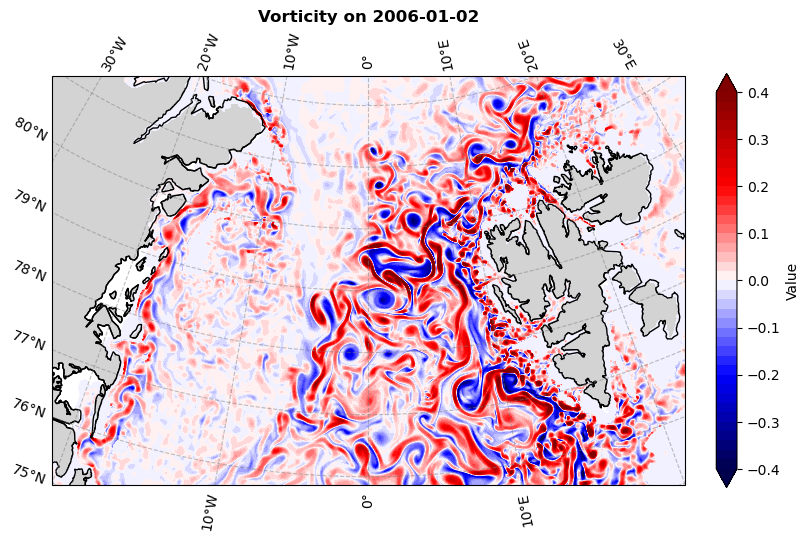

In [28]:
fig, ax = fplt.plot_polar_contourf(mesh, vorticity/f, levels=np.arange(-0.4, 0.4+0.02, 0.02), cmap="seismic", title=f"Vorticity on {str(ds_pf.time.values[time_idx])[:10]}", fill_num=0, show=False)

## Cross Check with Interpolated Regular Grid

In [21]:
ds_lsmask = xr.open_dataset("/albedo/home/quraus001/FESOM-FS-subduction/outdata/FESOM-FS-lsmask_regridded_lat825-lon800.nc")
ds_lsmask = ds_lsmask.rename({'__xarray_dataarray_variable__': 'lsmask'})
lsmask = ds_lsmask.lsmask

lon_new = np.linspace(-20, 20, 800)
lat_new = np.linspace(75, 82, 825)
lon_mesh, lat_mesh = np.meshgrid(lon_new, lat_new)

# Interpolate the data to the new grid
gridded_u = pf.fesom2regular(u, mesh, lon_mesh, lat_mesh , how='nn')
gridded_v = pf.fesom2regular(v, mesh, lon_mesh, lat_mesh , how='nn')


# Apply the mask to the gridded data
gridded_u[lsmask] = np.nan  # Set land points to NaN
gridded_v[lsmask] = np.nan  # Set land points to NaN

In [ ]:
import metpy.calc as mpcalc
from metpy.units import units

uQ = (gridded_u * units('m/s')) if not hasattr(gridded_u, 'units') else gridded_u
vQ = (gridded_v * units('m/s')) if not hasattr(gridded_v, 'units') else gridded_v
latQ = lat_mesh * units.degree
lonQ = lon_mesh * units.degree

uQ = units.Quantity(gridded_u, "m/s")
vQ = units.Quantity(gridded_v, "m/s")
latQ = units.Quantity(lat_mesh, "degree")
lonQ = units.Quantity(lon_mesh, "degree")

dx, dy = mpcalc.lat_lon_grid_deltas(lonQ, latQ)
print(uQ.shape, vQ.shape, dx.shape, dy.shape)
zeta = mpcalc.vorticity(uQ, vQ, dx=dx, dy=dy, x_dim=-1, y_dim=-2)  # 1/s

f_gridded = mpcalc.coriolis_parameter(latQ)  # 1/s
Ro = (zeta / f_gridded).to_base_units()   # dimensionless

(825, 800) (825, 800) (825, 799) (824, 800)


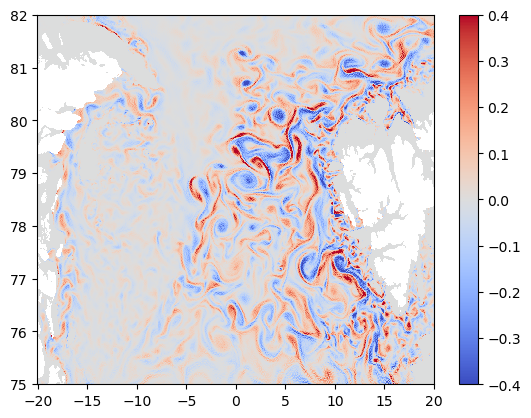

In [46]:
plt.pcolormesh(lon_new, lat_new, Ro, vmin=-0.4, vmax=0.4, cmap="coolwarm")
plt.colorbar()